In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

/home/bhaddock/envs/stan/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [ ]:
# params = pd.read_csv(
#     '/mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs/4PL_pure_rlu/model_files/m59/IndividualParameters/estimatedIndividualParameters.txt'
# )

# params = params.loc[params.id.str.contains("sample")]
# psummary = params[['id','alpha_mode','k_mode']].drop_duplicates()
# psummary.alpha_mode.mode(), psummary.k_mode.mode()

In [5]:
rows = np.repeat(np.arange(1, 9)[:, None], 12, axis=1)
cols = np.repeat(np.arange(1, 13)[None, :], 8, axis=0)

In [40]:
alpha = 163957
k = 15.2791
multi_edge_effect = 1 - alpha*(np.exp(-k*rows)+np.exp(-k*(9-rows))+np.exp(-k*cols)+np.exp(-k*(13-cols)))

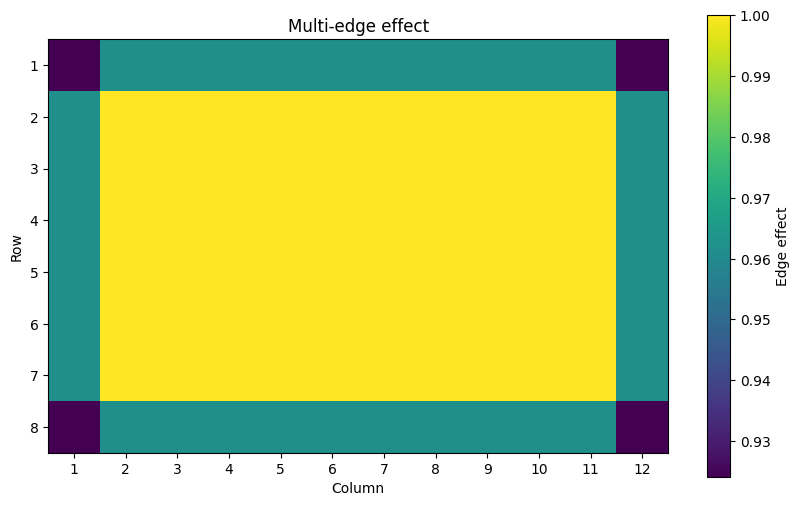

In [41]:
plt.figure(figsize=(10, 6))

plt.imshow(multi_edge_effect, cmap="viridis", origin="upper")
plt.colorbar(label="Edge effect")

plt.xticks(np.arange(12), np.arange(1, 13))
plt.yticks(np.arange(8), np.arange(1, 9))

plt.xlabel("Column")
plt.ylabel("Row")
plt.title("Multi-edge effect")

plt.show()

In [31]:
multi_edge_effect.min(), multi_edge_effect.max()

(np.float64(4.701265625928021e-22), np.float64(0.07588066712323717))

In [39]:
dist_to_nearest_edge = np.minimum(
    np.minimum(rows, 9-rows),
    np.minimum(cols, 13-cols)
)

In [42]:
nearest_edge_effect = 1 - alpha*np.exp(-k*dist_to_nearest_edge)

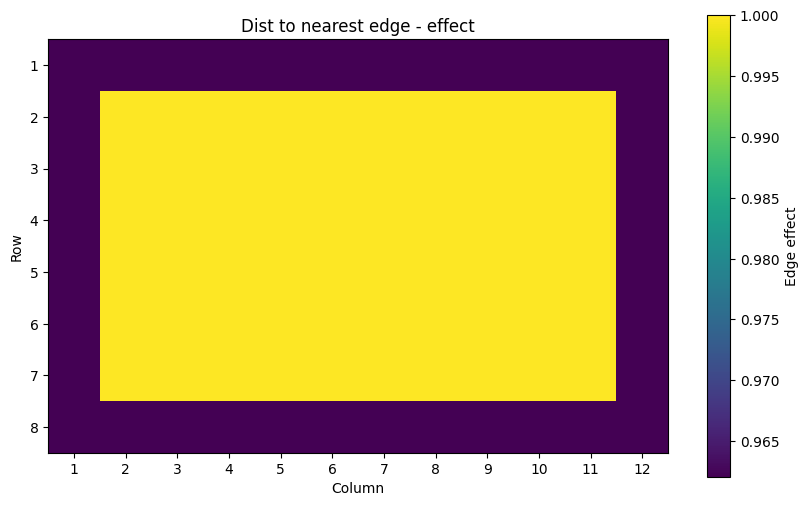

In [44]:
plt.figure(figsize=(10, 6))

plt.imshow(nearest_edge_effect, cmap="viridis", origin="upper")
plt.colorbar(label="Edge effect")

plt.xticks(np.arange(12), np.arange(1, 13))
plt.yticks(np.arange(8), np.arange(1, 9))

plt.xlabel("Column")
plt.ylabel("Row")
plt.title("Dist to nearest edge - effect")

plt.show()

In [45]:
dist_to_nearest_edge

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
       [1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1],
       [1, 2, 3, 4, 4, 4, 4, 4, 4, 3, 2, 1],
       [1, 2, 3, 4, 4, 4, 4, 4, 4, 3, 2, 1],
       [1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1],
       [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])